## Mini-Project 5: Taxi Route Revenue, Pricing & Fleet Planner

**Scenario.** A taxi (matatu) association runs 14-seater vehicles on three routes out of Kampala and wants to forecast demand, understand fares, and decide how many vehicles to deploy.



This notebook uses the `Route` class, the `RouteForecaster` subclasses, and `vehicles_needed()` defined in `src/project5_taxi.py`.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import solve

sys.path.insert(0, "../src")
from project5_taxi import (
    ExponentialSmoothingForecaster,
    LinearTrendForecaster,
    MovingAverageForecaster,
    Route,
    vehicles_needed,
)
from utils import mae

np.random.seed(42)

### Task 1: Routes and descriptive statistics

In [2]:
routes = {
    "Kampala-Ntinda": Route("Kampala-Ntinda", [35, 40, 42, 50, 55, 60, 48, 52, 47, 45], fare=2000),
    "Kampala-Entebbe": Route("Kampala-Entebbe", [60, 58, 65, 70, 72, 80, 75, 68, 66, 64], fare=5000),
    "Kampala-Mukono": Route("Kampala-Mukono", [45, 47, 50, 49, 55, 62, 58, 53, 51, 50], fare=3000),
}

for name, route in routes.items():
    stats = route.describe()
    print(f"{name}: total revenue = UGX {route.total_revenue():,.0f}")
    print(f"  daily revenue mean = UGX {stats['mean']:,.0f}, "
          f"variance = {stats['variance']:,.0f}, stdev = {stats['stdev']:,.0f}")

Kampala-Ntinda: total revenue = UGX 948,000
  daily revenue mean = UGX 94,800, variance = 217,066,667, stdev = 14,733
Kampala-Entebbe: total revenue = UGX 3,390,000
  daily revenue mean = UGX 339,000, variance = 1,126,666,667, stdev = 33,566
Kampala-Mukono: total revenue = UGX 1,560,000
  daily revenue mean = UGX 156,000, variance = 238,000,000, stdev = 15,427


### Task 2: Supply-demand equilibrium for the Ntinda route

`Qd = 120 - 0.02P` and `Qs = 10 + 0.03P`. Setting Qd = Qs gives the 2x2 linear system `Q + 0.02P = 120` and `Q - 0.03P = 10`, solved with `scipy.linalg.solve`.

In [3]:
A = np.array([[1.0, 0.02], [1.0, -0.03]])
b = np.array([120.0, 10.0])
equilibrium_q, equilibrium_p = solve(A, b)

print(f"Equilibrium quantity Q* = {equilibrium_q:.1f} passengers/trip-hour")
print(f"Equilibrium fare P*     = UGX {equilibrium_p:.0f}")

current_fare = routes["Kampala-Ntinda"].fare
if current_fare < equilibrium_p:
    print(f"\nCurrent fare (UGX {current_fare}) is BELOW equilibrium (UGX {equilibrium_p:.0f}): "
          "at this fare, demand exceeds supply (a shortage of seats).")
else:
    print(f"\nCurrent fare (UGX {current_fare}) is ABOVE equilibrium (UGX {equilibrium_p:.0f}): "
          "at this fare, supply exceeds demand (empty seats).")

Equilibrium quantity Q* = 76.0 passengers/trip-hour
Equilibrium fare P*     = UGX 2200

Current fare (UGX 2000) is BELOW equilibrium (UGX 2200): at this fare, demand exceeds supply (a shortage of seats).


### Tasks 3-4: forecasters, walk-forward backtesting (days 4-10), alpha grid search

At each origin day (4 through 9), each model is fit only on the data available up to that day and predicts the next day; the average absolute error across these origins is the walk-forward MAE.

In [4]:
def walk_forward_mae(model_factory, series):
    """Rolling-origin backtest: fit on data up to each origin day, predict the next day."""
    errors = []
    for origin in range(3, len(series) - 1):  # origins = day 4 .. day 9 (0-indexed 3..8)
        model = model_factory()
        model.fit(series[: origin + 1])
        errors.append(abs(series[origin + 1] - model.predict_next()))
    return mae(np.zeros(len(errors)), np.array(errors))  # mean of the absolute errors


alpha_grid = [0.1, 0.3, 0.5, 0.7, 0.9]
best_model_factory = {}

for name, route in routes.items():
    print(f"\n{name}")
    candidates = {
        "Moving average (3-day)": lambda: MovingAverageForecaster(window=3),
        "Linear trend": lambda: LinearTrendForecaster(),
    }
    best_alpha_mae = None
    for alpha in alpha_grid:
        model_mae = walk_forward_mae(lambda a=alpha: ExponentialSmoothingForecaster(alpha=a), route.passengers)
        if best_alpha_mae is None or model_mae < best_alpha_mae[1]:
            best_alpha_mae = (alpha, model_mae)
    candidates[f"Exp. smoothing (alpha={best_alpha_mae[0]})"] = (
        lambda a=best_alpha_mae[0]: ExponentialSmoothingForecaster(alpha=a)
    )

    scores = {label: walk_forward_mae(factory, route.passengers) for label, factory in candidates.items()}
    for label, score in scores.items():
        print(f"  {label}: walk-forward MAE = {score:.2f}")

    best_label = min(scores, key=scores.get)
    best_model_factory[name] = candidates[best_label]
    print(f"  -> best model: {best_label}")


Kampala-Ntinda
  Moving average (3-day): walk-forward MAE = 6.94
  Linear trend: walk-forward MAE = 8.52
  Exp. smoothing (alpha=0.9): walk-forward MAE = 5.48
  -> best model: Exp. smoothing (alpha=0.9)

Kampala-Entebbe
  Moving average (3-day): walk-forward MAE = 6.89
  Linear trend: walk-forward MAE = 8.33
  Exp. smoothing (alpha=0.9): walk-forward MAE = 4.57
  -> best model: Exp. smoothing (alpha=0.9)

Kampala-Mukono
  Moving average (3-day): walk-forward MAE = 5.94
  Linear trend: walk-forward MAE = 6.90
  Exp. smoothing (alpha=0.9): walk-forward MAE = 4.31
  -> best model: Exp. smoothing (alpha=0.9)


### Task 5: Day 11 forecast with the best model per route

Kampala-Ntinda: day 11 forecast = 45.2 passengers, revenue = UGX 90,494
Kampala-Entebbe: day 11 forecast = 64.2 passengers, revenue = UGX 321,137
Kampala-Mukono: day 11 forecast = 50.1 passengers, revenue = UGX 150,376


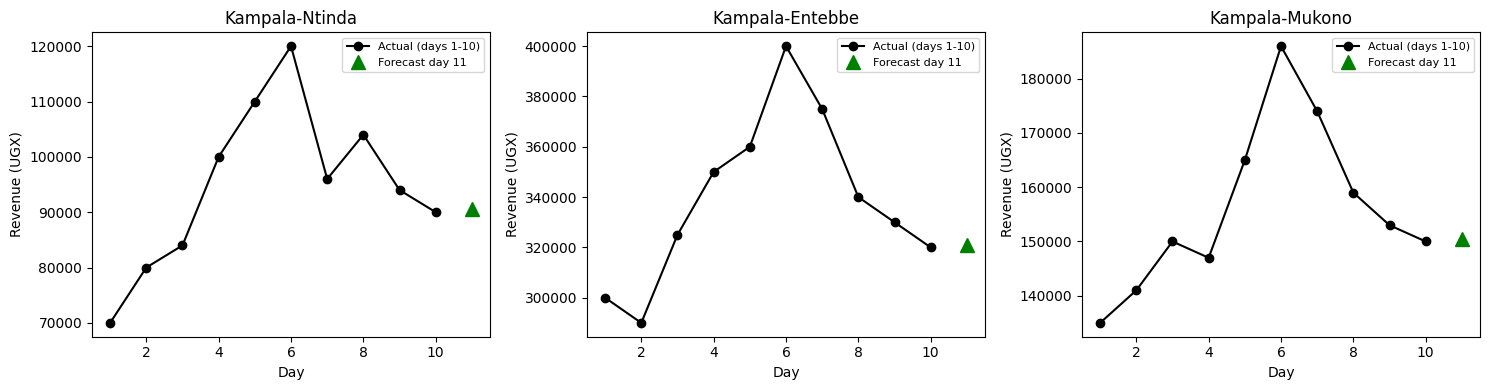

In [5]:
day11_passenger_forecast = {}
day11_revenue_forecast = {}

for name, route in routes.items():
    model = best_model_factory[name]()
    model.fit(route.passengers)
    forecast_passengers = model.predict_next()
    day11_passenger_forecast[name] = forecast_passengers
    day11_revenue_forecast[name] = forecast_passengers * route.fare
    print(f"{name}: day 11 forecast = {forecast_passengers:.1f} passengers, "
          f"revenue = UGX {day11_revenue_forecast[name]:,.0f}")

fig, axes = plt.subplots(1, len(routes), figsize=(15, 4))
days = np.arange(1, 11)
for ax, (name, route) in zip(axes, routes.items()):
    ax.plot(days, route.daily_revenue(), "o-", color="black", label="Actual (days 1-10)")
    ax.plot([11], [day11_revenue_forecast[name]], "^", color="green", markersize=10, label="Forecast day 11")
    ax.set_title(name)
    ax.set_xlabel("Day")
    ax.set_ylabel("Revenue (UGX)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Task 6: Fleet planning for day 11

Each vehicle makes 8 one-way trips per day at 14 passengers (112 passengers/day capacity), with a 15% safety buffer.

In [6]:
for name, forecast_passengers in day11_passenger_forecast.items():
    fleet = vehicles_needed(forecast_passengers, trips_per_day=8, seats=14, buffer=0.15)
    print(f"{name}: forecast {forecast_passengers:.1f} passengers -> deploy {fleet} vehicle(s) on day 11")

Kampala-Ntinda: forecast 45.2 passengers -> deploy 1 vehicle(s) on day 11
Kampala-Entebbe: forecast 64.2 passengers -> deploy 1 vehicle(s) on day 11
Kampala-Mukono: forecast 50.1 passengers -> deploy 1 vehicle(s) on day 11


## Findings & Limitations

Solving the supply-demand system gave an equilibrium fare of UGX 2,200 and quantity of 76 passengers/trip-hour for the Ntinda route. The current UGX 2,000 fare sits below this equilibrium, meaning demand (80 at UGX 2,000) exceeds supply (70), consistent with the notebook's observation of strong, growing passenger counts on that route - the association could likely raise the Ntinda fare somewhat without losing all excess demand. Walk-forward backtesting over days 4-10 consistently favoured exponential smoothing with a high alpha (0.9) over the 3-day moving average and linear trend for all three routes, meaning the most recent day's passenger count is the strongest predictor of the next day - the data has no strong linear trend over just 10 days, and short-term persistence matters more than a longer rolling average. Day 11 forecasts (45.2, 64.2 and 50.1 passengers for Ntinda, Entebbe and Mukono) each round up to a fleet requirement of exactly 1 vehicle per route once the 15% buffer is applied, since one 14-seater vehicle making 8 trips already covers 112 passengers/day - well above any single route's day-11 forecast.

**Limitations:** with only 10 days of data, the walk-forward backtest has very few origins (6 per route), so the "best" model per route is a fairly noisy choice and could change with more data or a different backtest window. The supply-demand curves (Qd, Qs) are illustrative assumptions, not measured from real fare-elasticity surveys, so the equilibrium fare should be treated as indicative, not a firm pricing recommendation. The fleet calculation also assumes every forecast passenger can be captured by exactly the routes and trip counts stated, ignoring practical scheduling constraints (traffic, breakdowns, uneven demand across the day).